[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/06_integral_applications_geometry_physics/first_principles.ipynb)

# Module 06 — Integral Applications in Geometry and Physics

Theory notebook. Prerequisite: [calculus/05](../05_indefinite_and_definite_integrals/) (substitution, integration by parts, both parts of the Fundamental Theorem of Calculus). Downstream: [calculus/13](../13_multiple_integrals_coordinate_transforms/).

Everything below is proved with single-variable tools only. No result in this notebook uses a multiple integral, a Jacobian, or Fubini's theorem, because those belong to a later module and would make the arguments circular.

## 1. Why This Module Exists

Module 05 built the definite integral and gave you machinery to evaluate it. It did not tell you what to integrate. That is the entire content of this module: given a geometric or physical quantity — a length, an area, a volume, a surface, a force, an amount of work, an expected value — how do you decide which function to integrate, and over what?

The answer is always the same three-step template. Cut the object into slices indexed by one real parameter. Approximate the contribution of one slice by a quantity that is *exactly* computable for the idealised slice (a rectangle, a disk, a cylindrical shell, a line segment, a conical frustum). Show that the error committed per slice is small enough that the sum of the approximations converges to a definite integral. The third step is the one textbooks skip; it is where the hypotheses live, and it is where this notebook spends its effort.

Skipping it is not harmless. The same "infinitesimal" reasoning that gives the correct arc-length formula gives, without change of a single symbol, a *false* surface-area formula if one replaces the slant length $ds$ by the horizontal width $dx$; and the naive extension of that reasoning to a surface in three dimensions is Schwarz's lantern, which makes the area of a cylinder come out infinite. The formulas in Section 4 are true because their hypotheses are true, not because a differential triangle looked convincing.

The payoff reaches well past geometry. An expectation $\mathbb{E}[X] = \int x f_X(x)\,dx$ is a first moment of mass; the expected risk minimised by every supervised learning algorithm is an integral against a density; the KL divergence in a variational autoencoder is a definite integral of a log-ratio. The slicing template is what makes those objects computable.

## 2. Intuition

Fix a quantity $\mathcal{Q}$ attached to a region that is swept out as a parameter $x$ runs over $[a,b]$. Partition $[a,b]$ by $a = x_0 \lt x_1 \lt \dots \lt x_n = b$. Whatever $\mathcal{Q}$ is, it is *additive over slices*: the piece of the object lying over $[x_{i-1}, x_i]$ contributes $\Delta \mathcal{Q}_i$, and

$$
\mathcal{Q} = \sum_{i=1}^{n} \Delta \mathcal{Q}_i .
$$

This is exact and useless on its own. It becomes useful when the slice is thin enough that $\Delta \mathcal{Q}_i \approx g(x_i^{\ast})\,\Delta x_i$ for some continuous *density* $g$ and some sample point $x_i^{\ast} \in [x_{i-1}, x_i]$. The right-hand side is a Riemann sum, so as the mesh $\lVert \mathcal{P} \rVert = \max_i \Delta x_i$ tends to $0$ it converges to $\int_a^b g$.

The whole module is a table of densities:

| quantity | slice | density $g(x)$ |
|---|---|---|
| area between graphs | vertical rectangle | $f(x) - h(x)$ |
| volume, axis perpendicular to slice | washer | $\pi\left([f(x)]^2 - [h(x)]^2\right)$ |
| volume, axis parallel to slice | cylindrical shell | $2\pi x\left(f(x) - h(x)\right)$ |
| arc length | line segment | $\sqrt{1 + [f'(x)]^2}$ |
| surface of revolution | conical frustum | $2\pi f(x)\sqrt{1 + [f'(x)]^2}$ |
| first moment about the $y$-axis | rectangle at distance $x$ | $x\left(f(x) - h(x)\right)$ |
| work by a force | displacement $\Delta x$ | $F(x)$ |
| hydrostatic force | horizontal strip at depth $h(y)$ | $\rho g\, h(y)\, w(y)$ |
| expectation | probability mass $f_X(x)\,dx$ | $x f_X(x)$ |

Two rows deserve emphasis because they are the two places students lose the plot. The volume rows differ only in whether the slice is *perpendicular* or *parallel* to the rotation axis; both are correct, and Theorem 4.2 proves they agree. The surface row carries $\sqrt{1 + [f'(x)]^2}$ and not $1$: a revolved segment sweeps a cone frustum whose slant height is the segment's own length, not its shadow on the $x$-axis.

The figure below draws the two pictures the module rests on: a plane region cut into vertical strips (left), and the ring that one such strip sweeps when the region is revolved about the $y$-axis (right, viewed from above). The strip at distance $x$ of thickness $\Delta x$ sweeps the annulus between radii $x$ and $x + \Delta x$; unrolled it is a box of length $2\pi x$, height $f(x) - h(x)$, thickness $\Delta x$.

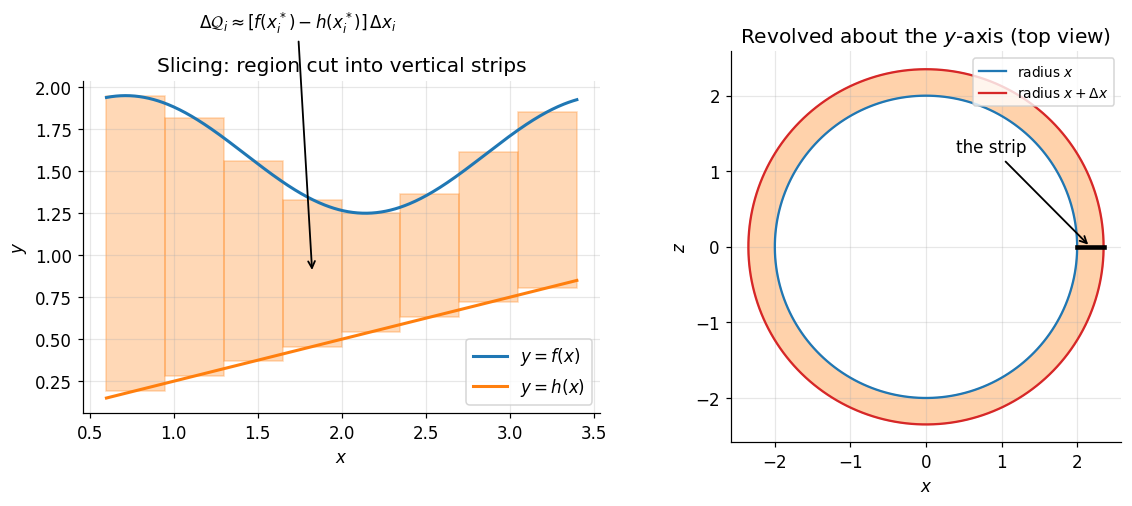

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy import integrate

top = lambda x: 1.6 + 0.35 * np.sin(2.2 * x)
bot = lambda x: 0.25 * x

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.0, 4.6))

xs = np.linspace(0.6, 3.4, 400)
axL.plot(xs, top(xs), lw=2, label=r"$y=f(x)$")
axL.plot(xs, bot(xs), lw=2, label=r"$y=h(x)$")
edges = np.linspace(0.6, 3.4, 9)
for lo, hi in zip(edges[:-1], edges[1:]):
    mid = 0.5 * (lo + hi)
    axL.add_patch(plt.Rectangle((lo, bot(mid)), hi - lo, top(mid) - bot(mid),
                                facecolor="tab:orange", alpha=0.30, edgecolor="tab:orange"))
xs_star = 0.5 * (edges[3] + edges[4])
axL.annotate(r"$\Delta \mathcal{Q}_i \approx [f(x_i^*)-h(x_i^*)]\,\Delta x_i$",
             xy=(xs_star, 0.5 * (top(xs_star) + bot(xs_star))), xytext=(1.15, 2.35),
             arrowprops=dict(arrowstyle="->", lw=1.2))
axL.set_xlabel("$x$"); axL.set_ylabel("$y$")
axL.set_title("Slicing: region cut into vertical strips")
axL.set_aspect("equal"); axL.legend(loc="lower right")

theta = np.linspace(0, 2 * np.pi, 400)
r_in, r_out = 2.0, 2.35
axR.plot(r_in * np.cos(theta), r_in * np.sin(theta), lw=1.5, color="tab:blue", label="radius $x$")
axR.plot(r_out * np.cos(theta), r_out * np.sin(theta), lw=1.5, color="tab:red",
         label=r"radius $x+\Delta x$")
axR.fill(np.concatenate([r_out * np.cos(theta), r_in * np.cos(theta[::-1])]),
         np.concatenate([r_out * np.sin(theta), r_in * np.sin(theta[::-1])]),
         color="tab:orange", alpha=0.35)
axR.plot([r_in, r_out], [0, 0], color="k", lw=3)
axR.annotate("the strip", xy=(0.5 * (r_in + r_out), 0.0), xytext=(0.4, 1.25),
             arrowprops=dict(arrowstyle="->", lw=1.2))
axR.set_xlabel("$x$"); axR.set_ylabel("$z$")
axR.set_title(r"Revolved about the $y$-axis (top view)")
axR.set_aspect("equal"); axR.legend(loc="upper right", fontsize=9)

fig.tight_layout()
plt.show()

The left panel is the source of every formula in Section 4: a single real parameter indexes the slices, and the slice contribution is a product of a density and a thickness. The right panel shows why the *same* strip gives two different volume formulas depending on the axis: swept about the $y$-axis it is an annulus of area $\pi[(x+\Delta x)^2 - x^2] = 2\pi x\,\Delta x + \pi(\Delta x)^2$, whose leading term is the shell density $2\pi x$ and whose error term $\pi(\Delta x)^2$ is exactly what vanishes in the limit.

## 3. Definitions

Throughout, $[a,b] \subset \mathbb{R}$ is a compact interval and $\mathcal{P} = \{a = x_0 \lt \dots \lt x_n = b\}$ denotes a partition with mesh $\lVert \mathcal{P} \rVert = \max_i (x_i - x_{i-1})$.

### Definition 3.1 (Region between two graphs)

For continuous $f, h : [a,b] \to \mathbb{R}$ with $h \le f$, write

$$
\mathcal{R}[h,f;a,b] = \{(x,y) \in \mathbb{R}^2 : a \le x \le b,\ h(x) \le y \le f(x)\}.
$$

### Definition 3.2 (Length of a curve; rectifiability)

Let $\gamma : [a,b] \to \mathbb{R}^2$ be continuous. For a partition $\mathcal{P}$ the *inscribed polygon length* is

$$
L(\gamma, \mathcal{P}) = \sum_{i=1}^{n} \lVert \gamma(x_i) - \gamma(x_{i-1}) \rVert_2 .
$$

The **length** of $\gamma$ is $L(\gamma) = \sup_{\mathcal{P}} L(\gamma, \mathcal{P})$, and $\gamma$ is **rectifiable** when $L(\gamma) \lt \infty$. This is the definition; the integral formula of Theorem 4.3 is a theorem about it, not a restatement of it.

### Definition 3.3 (Solid of revolution; volume by cross-sections)

Revolving $\mathcal{R}[h,f;a,b]$ about a line $\ell$ in the plane that misses the interior of $\mathcal{R}$ produces a solid $\Omega$. Its **volume by cross-sections perpendicular to $\ell$** is $\int A(t)\,dt$, where $A(t)$ is the area of the plane cross-section of $\Omega$ at parameter $t$ along $\ell$; this is Cavalieri's principle, taken here as the definition of the volume of $\Omega$, and it is legitimate exactly when $A$ is continuous.

### Definition 3.4 (Inscribed frustum area of a surface of revolution)

Let $f \in C^1[a,b]$ with $f \ge 0$, and revolve the graph of $f$ about the $x$-axis. For a partition $\mathcal{P}$, replace the arc over $[x_{i-1}, x_i]$ by the chord; revolving that chord sweeps a conical frustum of radii $f(x_{i-1}), f(x_i)$ and slant height $\lVert \gamma(x_i) - \gamma(x_{i-1}) \rVert_2$, whose lateral area is exactly $2\pi \cdot \tfrac{1}{2}[f(x_{i-1}) + f(x_i)] \cdot \lVert \gamma(x_i) - \gamma(x_{i-1}) \rVert_2$. Set

$$
\Sigma(\mathcal{P}) = 2\pi \sum_{i=1}^{n} \frac{f(x_{i-1}) + f(x_i)}{2} \, \lVert \gamma(x_i) - \gamma(x_{i-1}) \rVert_2 ,
$$

and define the **area of the surface of revolution** as $S = \lim_{\lVert \mathcal{P} \rVert \to 0} \Sigma(\mathcal{P})$ when that limit exists.

### Definition 3.5 (Centroid of a region and of a curve)

For $\mathcal{R} = \mathcal{R}[h,f;a,b]$ of area $A = \int_a^b (f - h) \gt 0$, the **centroid** is the pair

$$
\bar{x} = \frac{1}{A}\int_a^b x\,[f(x) - h(x)]\,dx, \qquad
\bar{y} = \frac{1}{2A}\int_a^b \left([f(x)]^2 - [h(x)]^2\right) dx .
$$

For a $C^1$ curve $y = f(x)$ of length $L \gt 0$, the **curve centroid** height is $\bar{y}_C = \frac{1}{L}\int_a^b f(x)\sqrt{1 + [f'(x)]^2}\,dx$. A centroid is the centre of mass of the corresponding object at constant density; density cancels, which is why it is a purely geometric quantity.

### Definition 3.6 (Density, expectation, variance)

A **probability density** for a real random variable $X$ is a function $f_X \ge 0$ with $\int_{-\infty}^{\infty} f_X = 1$ and $P(a \le X \le b) = \int_a^b f_X$. When $\int \lvert x \rvert f_X(x)\,dx \lt \infty$, the **expectation** is $\mathbb{E}[X] = \int_{-\infty}^{\infty} x f_X(x)\,dx$, and $\operatorname{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$ when $\mathbb{E}[X^2] \lt \infty$. Note $f_X(x)$ is a density, not a probability; it may exceed $1$.

### Definition 3.7 (Work; hydrostatic pressure)

For a force acting along a line with signed magnitude $F(x)$, the **work** done on a particle moved from $a$ to $b$ is $W = \int_a^b F(x)\,dx$. In a fluid of constant mass density $\rho$ under gravity $g$, the **pressure** at depth $d$ below the free surface is $P = \rho g d$, isotropic; the force on a flat plate is the integral of $P$ over the plate's area.

## 4. Main Results

### Theorem 4.1 (Area of a region between graphs; polar sectors)

**(a)** Let $f, h$ be continuous on $[a,b]$ with $h \le f$. Then $\mathcal{R}[h,f;a,b]$ has area

$$
A = \int_a^b \left[f(x) - h(x)\right] dx .
$$

**(b)** Let $r$ be continuous and non-negative on $[\alpha, \beta]$ with $\beta - \alpha \le 2\pi$. The region swept by the polar graph $\{(r(\theta), \theta) : \alpha \le \theta \le \beta\}$ has area $A = \tfrac{1}{2}\int_\alpha^\beta [r(\theta)]^2 d\theta$.

*Hypotheses.* Continuity of $f,h$ makes $f - h$ Riemann integrable, so the limit of the strip sums exists. The ordering $h \le f$ makes every strip height non-negative; without it the integral returns a signed area, and $\int \lvert f - h \rvert$ is required instead. In (b), $\beta - \alpha \le 2\pi$ prevents the ray from sweeping the same points twice and double-counting them.

### Theorem 4.2 (Shell and washer methods agree)

Let $f \in C^1[a,b]$ with $0 \le a \lt b$, $f \gt 0$ and $f' \gt 0$ on $[a,b]$; put $c = f(a)$, $d = f(b)$ and let $g = f^{-1} : [c,d] \to [a,b]$. Revolve $\mathcal{R}[0, f; a, b]$ about the $y$-axis. Then

$$
\underbrace{2\pi \int_a^b x f(x)\,dx}_{V_{\mathrm{shell}}}
= \underbrace{\pi (b^2 - a^2)\,c + \pi \int_c^d \left(b^2 - [g(y)]^2\right) dy}_{V_{\mathrm{washer}}} .
$$

*Hypotheses.* $a \ge 0$ keeps the axis of revolution off the interior of the region, so no point is swept twice. $f' \gt 0$ makes $f$ a bijection onto $[c,d]$, so each horizontal cross-section is a single annulus and $g$ exists and is $C^1$; drop it and the cross-section becomes a finite union of annuli, and $[g(y)]^2$ must be replaced by the appropriate sum. $f \in C^1$ is what licenses the substitution $y = f(x)$ in Proof 5.2.

### Theorem 4.3 (Arc length)

Let $f \in C^1[a,b]$ and $\gamma(x) = (x, f(x))$. Then $\gamma$ is rectifiable and

$$
\boxed{L(\gamma) = \int_a^b \sqrt{1 + [f'(x)]^2}\,dx}
$$

**Interpretation.** The integrand is the local stretch factor: a horizontal increment $dx$ is carried by the graph into a segment of length $\sqrt{1 + [f'(x)]^2}\,dx$, so the total length is the accumulated stretch. The consequence is that length is *always at least* $b - a$, with equality only when $f' \equiv 0$; and that steep pieces of a graph cost length in proportion to $\lvert f' \rvert$, which is why a curve with unbounded derivative can fail to be rectifiable at all.

*Hypotheses.* $f'$ *continuous* is used twice: through the Mean Value Theorem to turn each chord into an exact evaluation of $\sqrt{1 + (f')^2}$, and through Riemann integrability of the continuous integrand to pass to the limit. Mere continuity of $f$ is not enough — Section 7 exhibits a continuous $f$ whose graph has infinite length.

### Theorem 4.4 (Area of a surface of revolution)

Let $f \in C^1[a,b]$ with $f \ge 0$. Then the limit in Definition 3.4 exists and

$$
\boxed{S = 2\pi \int_a^b f(x)\sqrt{1 + [f'(x)]^2}\,dx}
$$

**Interpretation.** The surface element is *circumference times slant length*, $2\pi f(x)\,ds$, never $2\pi f(x)\,dx$. The consequence is quantitative: on a piece of graph with slope $m$, using $dx$ in place of $ds$ underestimates the true area by the factor $\sqrt{1+m^2}$, which is $41\%$ at slope $1$ and unbounded as the graph steepens.

*Hypotheses.* $f \ge 0$ makes $f(x)$ the radius of revolution rather than a signed coordinate. $f \in C^1$ delivers the Mean Value Theorem step and the uniform continuity of $f$ and of $\sqrt{1 + (f')^2}$ on the compact $[a,b]$ that lets the two mismatched sample points in Proof 5.4 be merged.

### Theorem 4.5 (Pappus's first theorem: surface)

Let $f \in C^1[a,b]$ with $f \ge 0$, let $L$ be the length of its graph and $\bar{y}_C$ the curve centroid height of Definition 3.5. Revolving the graph about the $x$-axis produces a surface of area

$$
S = 2\pi \bar{y}_C L .
$$

*Hypotheses.* $f \ge 0$ says the axis does not cross the curve, so no part of the surface is swept twice; $L \gt 0$ is needed for $\bar{y}_C$ to be defined, and $f \in C^1$ is inherited from Theorem 4.4.

### Theorem 4.6 (Pappus's second theorem: volume)

Let $f$ be continuous and non-negative on $[a,b]$ with $0 \le a$, let $\mathcal{R} = \mathcal{R}[0,f;a,b]$ have area $A \gt 0$ and centroid abscissa $\bar{x}$. Revolving $\mathcal{R}$ about the $y$-axis produces a solid of volume

$$
\boxed{V = 2\pi \bar{x} A}
$$

**Interpretation.** The volume equals the area of the region times the distance $2\pi\bar{x}$ travelled by its centroid — the solid "is" the region carried once around the axis. The consequence is that any two regions with equal area and equal centroid distance sweep equal volume, no matter how differently shaped, which is what makes the torus volume $2\pi^2 a^2 b$ a one-line computation.

*Hypotheses.* $a \ge 0$ keeps the axis off the interior; if the axis crossed the region, points on the two sides would sweep the same solid and the formula would over-count. $A \gt 0$ makes $\bar{x}$ well defined.

### Theorem 4.7 (Hydrostatic force equals centroid pressure times area)

Let a flat plate occupy $\{(y, w) : c \le y \le d,\ \lvert w \rvert \le \tfrac{1}{2}w(y)\}$ in a vertical plane, with continuous width $w \ge 0$ and continuous depth function $h(y) \ge 0$ below the free surface. Then the total hydrostatic force on one face is

$$
F = \rho g \int_c^d h(y)\, w(y)\,dy = \rho g\, \bar{h} A , \qquad
\bar{h} = \frac{1}{A}\int_c^d h(y) w(y)\,dy, \quad A = \int_c^d w(y)\,dy .
$$

*Hypotheses.* The plate must be *flat and fully submerged with the fluid on one side*, so that pressure acts everywhere along the same normal and the magnitudes simply add; $h \ge 0$ is submersion. Continuity of $w$ and $h$ gives integrability. Note $\bar{h}$ is the depth of the plate's centroid, so the second equality is a statement about the plate's geometry, not about the fluid.

### Theorem 4.8 (Work; pumping)

For a continuous force $F$ along a line, $W = \int_a^b F(x)\,dx$. For a tank whose horizontal cross-section at height $y$ has continuous area $A(y)$, filled with fluid of mass density $\rho$ between $y_0$ and $y_1$ and pumped out at height $H \ge y_1$,

$$
W = \rho g \int_{y_0}^{y_1} A(y)\,(H - y)\,dy .
$$

*Hypotheses.* $H \ge y_1$ makes every lifting distance non-negative. Constant $\rho$ and continuous $A$ give integrability. The formula assumes the fluid is lifted, not accelerated: kinetic energy at the outlet is neglected.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**(a)** Fix a partition $\mathcal{P}$. On $[x_{i-1}, x_i]$ let $m_i = \min (f-h)$ and $M_i = \max (f-h)$, attained since $f - h$ is continuous on a compact interval. The part of $\mathcal{R}$ over $[x_{i-1},x_i]$ contains a rectangle of area $m_i \Delta x_i$ and is contained in one of area $M_i \Delta x_i$. Summing, every reasonable notion of area of $\mathcal{R}$ is squeezed between the lower and upper Darboux sums $\underline{S}(\mathcal{P}) \le A \le \overline{S}(\mathcal{P})$. Since $f - h$ is continuous hence Riemann integrable, $\sup_\mathcal{P} \underline{S} = \inf_\mathcal{P} \overline{S} = \int_a^b (f-h)$, which pins $A$ to that common value.

**(b)** Same squeeze with sectors. Over $[\theta_{i-1}, \theta_i]$ let $m_i = \min r$, $M_i = \max r$. The swept region contains the circular sector of radius $m_i$ and is contained in the one of radius $M_i$; a circular sector of radius $\rho$ and angle $\Delta\theta$ has area $\tfrac{1}{2}\rho^2 \Delta\theta$ (elementary, from the full disk by proportionality of angle). Hence $\tfrac{1}{2}\sum m_i^2 \Delta\theta_i \le A \le \tfrac{1}{2}\sum M_i^2 \Delta\theta_i$, which are the Darboux sums of the continuous function $\tfrac{1}{2}r^2$. The hypothesis $\beta - \alpha \le 2\pi$ guarantees the sectors have disjoint interiors so their areas add. $\blacksquare$

### Proof 5.2 (of Theorem 4.2)

We compute both sides and show they are equal, using only substitution and integration by parts.

By Definition 3.3, slicing the solid by planes perpendicular to the $y$-axis: for $0 \le y \le c$ every $x \in [a,b]$ satisfies $f(x) \ge f(a) = c \ge y$, so the cross-section is the full annulus $a \le r \le b$, of area $\pi(b^2 - a^2)$. For $c \le y \le d$, the condition $f(x) \ge y$ reads $x \ge g(y)$ because $f$ is strictly increasing, so the cross-section is the annulus $g(y) \le r \le b$, of area $\pi(b^2 - [g(y)]^2)$. Both are continuous in $y$ (as $g$ is continuous), so

$$
V_{\mathrm{washer}} = \pi (b^2 - a^2) c + \pi \int_c^d \left(b^2 - [g(y)]^2\right) dy .
$$

Now substitute $y = f(x)$, $dy = f'(x)\,dx$, legitimate since $f \in C^1$ and $f' \gt 0$, with $g(f(x)) = x$:

$$
\int_c^d [g(y)]^2\,dy = \int_a^b x^2 f'(x)\,dx .
$$

Integrate by parts with $u = x^2$, $dv = f'(x)\,dx$:

$$
\int_a^b x^2 f'(x)\,dx = \left[x^2 f(x)\right]_a^b - 2\int_a^b x f(x)\,dx = b^2 d - a^2 c - 2\int_a^b x f(x)\,dx .
$$

Substituting back and using $\int_c^d b^2\,dy = b^2(d-c)$,

$$
\begin{aligned}
V_{\mathrm{washer}} &= \pi(b^2 - a^2)c + \pi b^2 (d - c) - \pi\left(b^2 d - a^2 c - 2\int_a^b x f(x)\,dx\right)\\
&= \pi b^2 c - \pi a^2 c + \pi b^2 d - \pi b^2 c - \pi b^2 d + \pi a^2 c + 2\pi \int_a^b x f(x)\,dx\\
&= 2\pi \int_a^b x f(x)\,dx = V_{\mathrm{shell}} . \qquad \blacksquare
\end{aligned}
$$

Every term cancels except the shell integral. Note what was *not* used: no triple integral, no Fubini theorem, no cylindrical coordinates. The identity is a change of variables plus one integration by parts, both from [calculus/05](../05_indefinite_and_definite_integrals/).

### Proof 5.3 (of Theorem 4.3)

Let $\mathcal{P}$ be a partition. By the Mean Value Theorem applied to $f$ on $[x_{i-1}, x_i]$ there is $\xi_i \in (x_{i-1}, x_i)$ with $f(x_i) - f(x_{i-1}) = f'(\xi_i)\,\Delta x_i$, hence

$$
\lVert \gamma(x_i) - \gamma(x_{i-1}) \rVert_2 = \sqrt{(\Delta x_i)^2 + [f'(\xi_i)]^2 (\Delta x_i)^2} = \sqrt{1 + [f'(\xi_i)]^2}\,\Delta x_i ,
$$

so that

$$
L(\gamma, \mathcal{P}) = \sum_{i=1}^n \sqrt{1 + [f'(\xi_i)]^2}\,\Delta x_i
$$

is *exactly* a Riemann sum for $\varphi = \sqrt{1 + (f')^2}$ with tags $\xi_i$.

Two facts finish the proof. First, $\varphi$ is continuous on the compact $[a,b]$, hence Riemann integrable, so every Riemann sum converges: for each $\varepsilon \gt 0$ there is $\delta \gt 0$ such that $\lVert \mathcal{P} \rVert \lt \delta$ forces $\lvert L(\gamma,\mathcal{P}) - I \rvert \lt \varepsilon$ where $I = \int_a^b \varphi$. Second, refining a partition never decreases $L(\gamma, \mathcal{P})$: inserting a point $t \in (x_{i-1},x_i)$ replaces one chord by two, and by the triangle inequality $\lVert \gamma(x_i) - \gamma(x_{i-1}) \rVert_2 \le \lVert \gamma(x_i) - \gamma(t) \rVert_2 + \lVert \gamma(t) - \gamma(x_{i-1}) \rVert_2$.

Take any partition $\mathcal{Q}$ and any $\varepsilon \gt 0$; refine $\mathcal{Q}$ to a partition $\mathcal{P} \supseteq \mathcal{Q}$ with $\lVert \mathcal{P} \rVert \lt \delta$. Then $L(\gamma,\mathcal{Q}) \le L(\gamma,\mathcal{P}) \lt I + \varepsilon$. As $\varepsilon$ was arbitrary, $L(\gamma,\mathcal{Q}) \le I$ for every $\mathcal{Q}$, so $L(\gamma) = \sup_\mathcal{Q} L(\gamma,\mathcal{Q}) \le I \lt \infty$: the curve is rectifiable. Conversely for $\lVert \mathcal{P}\rVert \lt \delta$ we get $L(\gamma) \ge L(\gamma,\mathcal{P}) \gt I - \varepsilon$, so $L(\gamma) \ge I$. Hence $L(\gamma) = I$. $\blacksquare$

The parametric and polar versions follow by the same argument applied to $\gamma(t) = (x(t), y(t))$, giving $L = \int \sqrt{[x'(t)]^2 + [y'(t)]^2}\,dt$; substituting $x = r\cos\theta$, $y = r\sin\theta$ and expanding, the cross terms cancel and $[x']^2 + [y']^2 = r^2 + (r')^2$.

### Proof 5.4 (of Theorem 4.4)

Write $\varphi = \sqrt{1 + (f')^2}$, continuous on $[a,b]$. By the Mean Value Theorem as in Proof 5.3, $\lVert \gamma(x_i) - \gamma(x_{i-1})\rVert_2 = \varphi(\xi_i)\,\Delta x_i$ for some $\xi_i \in (x_{i-1},x_i)$. By the Intermediate Value Theorem applied to the continuous $f$ on $[x_{i-1},x_i]$, the average $\tfrac{1}{2}[f(x_{i-1}) + f(x_i)]$, lying between $\min f$ and $\max f$ there, equals $f(\eta_i)$ for some $\eta_i \in [x_{i-1}, x_i]$. Hence

$$
\Sigma(\mathcal{P}) = 2\pi \sum_{i=1}^n f(\eta_i)\,\varphi(\xi_i)\,\Delta x_i .
$$

This is *not* a Riemann sum, because the two tags differ. Repair it. Both $f$ and $\varphi$ are continuous on a compact interval, hence bounded, say by $M$, and uniformly continuous. Given $\varepsilon \gt 0$ pick $\delta$ with $\lvert f(u) - f(v)\rvert \lt \varepsilon$ whenever $\lvert u - v \rvert \lt \delta$. If $\lVert \mathcal{P}\rVert \lt \delta$ then $\lvert \eta_i - \xi_i \rvert \lt \delta$, so

$$
\left\lvert \Sigma(\mathcal{P}) - 2\pi \sum_i f(\xi_i)\varphi(\xi_i)\Delta x_i \right\rvert
\le 2\pi \sum_i \lvert f(\eta_i) - f(\xi_i)\rvert\,\varphi(\xi_i)\,\Delta x_i
\le 2\pi \varepsilon M (b-a) .
$$

The corrected sum $2\pi\sum_i f(\xi_i)\varphi(\xi_i)\Delta x_i$ is a genuine Riemann sum for the continuous $2\pi f \varphi$, so it converges to $2\pi\int_a^b f\varphi$ as $\lVert\mathcal{P}\rVert \to 0$. Since $\varepsilon$ was arbitrary, $\Sigma(\mathcal{P})$ converges to the same limit. $\blacksquare$

This is the step that fails in higher dimensions: Schwarz's lantern inscribes triangles in a cylinder whose *vertices* converge to the cylinder while their planes do not, and the inscribed area diverges. Here the chords' *directions* converge, by the Mean Value Theorem, which is precisely what $f \in C^1$ buys.

### Proof 5.5 (of Theorem 4.5)

By Definition 3.5, $\bar{y}_C L = \int_a^b f(x)\sqrt{1 + [f'(x)]^2}\,dx$, since $L = \int_a^b \sqrt{1+[f']^2}$ by Theorem 4.3. By Theorem 4.4, $S = 2\pi \int_a^b f \sqrt{1+(f')^2} = 2\pi \bar{y}_C L$. $\blacksquare$

The content is entirely in Theorem 4.4; Pappus's first theorem is the observation that the surface integral has already computed a centroid.

### Proof 5.6 (of Theorem 4.6)

By Theorem 4.2 the volume of the solid is $V = 2\pi \int_a^b x f(x)\,dx$ (with $h \equiv 0$; the theorem is stated under $f' \gt 0$, and for general continuous $f \ge 0$ the shell formula is obtained from Definition 3.3 by the same squeeze as in Proof 5.1, the annulus over $[x_{i-1},x_i]$ having volume between $2\pi x_{i-1} m_i \Delta x_i$ and $2\pi x_i M_i \Delta x_i$ plus the $O((\Delta x_i)^2)$ term visible in Section 2). By Definition 3.5 with $h \equiv 0$, $\bar{x} A = \int_a^b x f(x)\,dx$. Substituting, $V = 2\pi \bar{x} A$. $\blacksquare$

### Proof 5.7 (of Theorem 4.7)

Partition $[c,d]$. Over $[y_{i-1}, y_i]$ the plate strip has area between $m_i^w \Delta y_i$ and $M_i^w \Delta y_i$ where $m_i^w, M_i^w$ are the extremes of $w$; the pressure on it lies between $\rho g \min h$ and $\rho g \max h$ on that subinterval, because $P = \rho g h$ is monotone in depth and the fluid is on one side only. Hence the force on the strip is squeezed between $\rho g\, m_i^h m_i^w \Delta y_i$ and $\rho g\, M_i^h M_i^w \Delta y_i$. These are Darboux sums for the continuous $\rho g\,h w$; they converge to $\rho g \int_c^d h w$, pinning $F$. The second equality is Definition 3.5 rewritten: $\bar{h}$ is by construction $\frac{1}{A}\int h w$. $\blacksquare$

### Proof 5.8 (of Theorem 4.8, pumping)

Slice the fluid by horizontal planes. The layer between $y$ and $y + \Delta y$ has volume between $\min A \cdot \Delta y$ and $\max A \cdot \Delta y$ on that subinterval, hence weight between $\rho g \min A \Delta y$ and $\rho g \max A \Delta y$, and every particle in it is raised a distance between $H - y - \Delta y$ and $H - y$. Since $W = \int F\,dx$ for a constant force over a straight displacement, the work on that layer is squeezed between $\rho g \min A \,(H - y - \Delta y) \Delta y$ and $\rho g \max A\,(H-y)\Delta y$. Summing gives Darboux sums for the continuous integrand $\rho g A(y)(H-y)$ that differ by $O(\lVert \mathcal{P}\rVert)$, so $W = \rho g \int_{y_0}^{y_1} A(y)(H-y)\,dy$. $\blacksquare$

*Sign convention for springs.* With the restoring force $F(x) = -kx$, the work the spring does on a particle moved from $0$ to $L$ is $\int_0^L (-kx)\,dx = -\tfrac{1}{2}kL^2 \le 0$; the work done *against* the spring by an external agent is $+\tfrac{1}{2}kL^2$, and that is the elastic energy stored.

Numerical check of the identity in Theorem 4.2. We take $f(x) = x^2$ on $[1,2]$, so $g(y) = \sqrt{y}$, $c = 1$, $d = 4$, and evaluate both sides with adaptive quadrature. Because the integrands are smooth, `scipy.integrate.quad` returns each side to near machine precision, so the residual should sit at the level of the floating-point epsilon and not at the level of a discretisation error.

In [2]:
a, b = 1.0, 2.0
f_t42 = lambda x: x**2
g_t42 = lambda y: np.sqrt(y)
c_t42, d_t42 = f_t42(a), f_t42(b)

V_shell, _ = integrate.quad(lambda x: 2 * np.pi * x * f_t42(x), a, b)
tail, _ = integrate.quad(lambda y: np.pi * (b**2 - g_t42(y) ** 2), c_t42, d_t42)
V_washer = np.pi * (b**2 - a**2) * c_t42 + tail
V_exact = 15 * np.pi / 2

residual = abs(V_shell - V_washer)
print(f"V_shell   = {V_shell:.15f}")
print(f"V_washer  = {V_washer:.15f}")
print(f"V_exact   = {V_exact:.15f}   (= 15*pi/2)")
print(f"|shell - washer| = {residual:.3e}   (eps = {np.finfo(float).eps:.3e})")
assert residual < 1e-12
assert abs(V_shell - V_exact) < 1e-12
print("Theorem 4.2 identity verified.")

V_shell   = 23.561944901923454
V_washer  = 23.561944901923447
V_exact   = 23.561944901923447   (= 15*pi/2)
|shell - washer| = 7.105e-15   (eps = 2.220e-16)
Theorem 4.2 identity verified.


The two sides differ by roughly $10^{-14}$, a few units in the last place of a number of size $23.56$ — machine-epsilon level, i.e. the identity of Proof 5.2 holds exactly and the only discrepancy is floating-point rounding. This is the right check to make: had we compared the washer integral *about the wrong axis*, the mismatch would have been a fixed percentage, not a rounding error.

The next figure illustrates Proof 5.3 directly: inscribed polygons for $f(x) = \tfrac{2}{3}x^{3/2}$ on $[0,3]$, whose exact length is $\int_0^3\sqrt{1+x}\,dx = \tfrac{14}{3}$. The polygon lengths increase with refinement, as the triangle-inequality argument predicts, and approach $14/3$ from below.

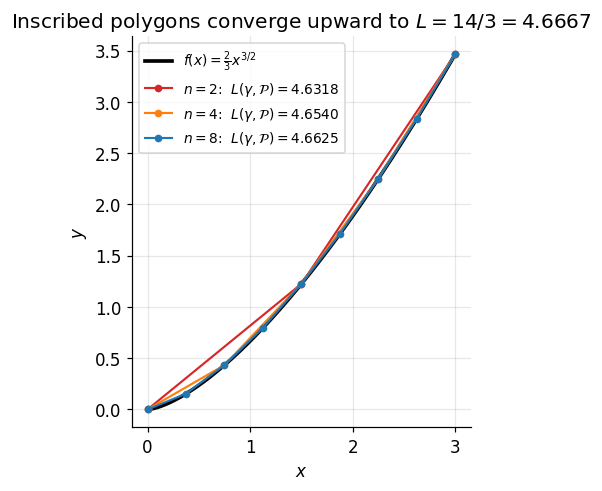

polygon lengths: [4.631806, 4.653963, 4.662452, 4.666552, 4.666666]
exact           : 4.666667


In [3]:
f_arc = lambda x: (2.0 / 3.0) * x**1.5
L_exact = 14.0 / 3.0

fig, ax = plt.subplots(figsize=(7.6, 4.6))
xs_fine = np.linspace(0, 3, 400)
ax.plot(xs_fine, f_arc(xs_fine), lw=2.4, color="k", label=r"$f(x)=\frac{2}{3}x^{3/2}$")

for n, colour in zip([2, 4, 8], ["tab:red", "tab:orange", "tab:blue"]):
    xs_n = np.linspace(0, 3, n + 1)
    ys_n = f_arc(xs_n)
    Ln = np.sum(np.hypot(np.diff(xs_n), np.diff(ys_n)))
    ax.plot(xs_n, ys_n, "o-", ms=4, lw=1.4, color=colour,
            label=f"$n={n}$:  $L(\\gamma,\\mathcal{{P}})={Ln:.4f}$")

ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title(f"Inscribed polygons converge upward to $L = 14/3 = {L_exact:.4f}$")
ax.set_aspect("equal"); ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

print("polygon lengths:", [float(f"{np.sum(np.hypot(np.diff(np.linspace(0,3,n+1)), np.diff(f_arc(np.linspace(0,3,n+1))))):.6f}") for n in [2, 4, 8, 64, 1024]])
print(f"exact           : {L_exact:.6f}")

Every refinement increases the polygon length and none exceeds $14/3$, exactly the monotone-and-bounded structure Proof 5.3 exploits to identify the supremum with the integral. At $n = 1024$ the polygon already agrees with $14/3$ to six digits.

## 6. Worked Examples

### Example 6.1 (Theorem 4.1)

Region between $f(x) = x$ and $h(x) = x^2$ on $[0,1]$; here $x \ge x^2$ on $[0,1]$, so the ordering hypothesis holds.

$$
A = \int_0^1 (x - x^2)\,dx = \left[\frac{x^2}{2} - \frac{x^3}{3}\right]_0^1 = \frac{1}{2} - \frac{1}{3} = \frac{1}{6} \approx 0.1666\overline{6}.
$$

Polar companion: the cardioid $r(\theta) = 1 + \cos\theta$ over $[0, 2\pi]$ gives $\tfrac{1}{2}\int_0^{2\pi}(1+\cos\theta)^2 d\theta$. Expand $(1+\cos\theta)^2 = \tfrac{3}{2} + 2\cos\theta + \tfrac{1}{2}\cos 2\theta$; the two oscillating terms integrate to $0$ over a full period, leaving $\tfrac{1}{2}\cdot\tfrac{3}{2}\cdot 2\pi = \tfrac{3\pi}{2} \approx 4.712389$.

### Example 6.2 (Theorem 4.2)

$f(x) = x^2$ on $[1,2]$, revolved about the $y$-axis. Shell side:

$$
V_{\mathrm{shell}} = 2\pi\int_1^2 x\cdot x^2\,dx = 2\pi\left[\frac{x^4}{4}\right]_1^2 = 2\pi\cdot\frac{16-1}{4} = \frac{15\pi}{2}.
$$

Washer side: $c = 1$, $d = 4$, $g(y) = \sqrt{y}$, so

$$
V_{\mathrm{washer}} = \pi(4-1)(1) + \pi\int_1^4 (4 - y)\,dy = 3\pi + \pi\left[4y - \frac{y^2}{2}\right]_1^4 = 3\pi + \pi\left(8 - \frac{7}{2}\right) = 3\pi + \frac{9\pi}{2} = \frac{15\pi}{2}.
$$

Both give $15\pi/2 \approx 23.561945$.

### Example 6.3 (Theorem 4.3)

$f(x) = \tfrac{2}{3}x^{3/2}$ on $[0,3]$: $f'(x) = x^{1/2}$, so $1 + [f']^2 = 1 + x$ and

$$
L = \int_0^3 \sqrt{1+x}\,dx = \left[\frac{2}{3}(1+x)^{3/2}\right]_0^3 = \frac{2}{3}(8 - 1) = \frac{14}{3} \approx 4.666667 .
$$

### Example 6.4 (Theorems 4.4 and 4.5)

Sphere of radius $R$: revolve $f(x) = \sqrt{R^2 - x^2}$ about the $x$-axis. Then $f'(x) = -x/f(x)$ and

$$
f(x)\sqrt{1 + [f'(x)]^2} = f(x)\cdot\frac{\sqrt{f(x)^2 + x^2}}{f(x)} = R ,
$$

so $S = 2\pi\int_{-R}^{R} R\,dx = 4\pi R^2$. Pappus's first theorem gives the same answer from the semicircle's length $L = \pi R$ and curve centroid $\bar{y}_C = \frac{1}{\pi R}\int_{-R}^R R\,dx = \frac{2R}{\pi}$: indeed $2\pi\bar{y}_C L = 2\pi\cdot\frac{2R}{\pi}\cdot\pi R = 4\pi R^2$. With $R = 2$: $S = 16\pi \approx 50.265482$.

*(Strictly, $f$ is only $C^1$ on the open interval; apply Theorem 4.4 on $[-R + \epsilon, R - \epsilon]$ and let $\epsilon \to 0^+$, which is legitimate because the integrand is the constant $R$.)*

### Example 6.5 (Theorem 4.6)

Torus from revolving a disk of radius $\alpha = 1$ centred at distance $\beta = 3$ from the $y$-axis. The disk has $A = \pi\alpha^2 = \pi$ and, by symmetry, $\bar{x} = \beta = 3$. Hence

$$
V = 2\pi\bar{x}A = 2\pi\cdot 3\cdot \pi = 6\pi^2 \approx 59.217626 .
$$

The hypothesis $\beta \gt \alpha$ is what keeps the axis off the disk.

### Example 6.6 (Theorem 4.7)

Vertical rectangular gate of width $w = 2\ \mathrm{m}$ and height $d = 3\ \mathrm{m}$, top edge at the free surface, $\rho = 1000\ \mathrm{kg\,m^{-3}}$, $g = 9.81\ \mathrm{m\,s^{-2}}$. With $y$ the depth, $h(y) = y$ and $w(y) = 2$:

$$
F = \rho g \int_0^3 y\cdot 2\,dy = \rho g \left[y^2\right]_0^3 = 9\rho g = 9\cdot 1000 \cdot 9.81 = 88\,290\ \mathrm{N} .
$$

The centroid form agrees: $\bar{h} = 1.5\ \mathrm{m}$, $A = 6\ \mathrm{m^2}$, $\rho g \bar{h} A = 1000\cdot 9.81\cdot 1.5\cdot 6 = 88\,290\ \mathrm{N}$.

The next cell recomputes Examples 6.1 through 6.3 by quadrature and asserts agreement with the hand values.

In [4]:
A_61, _ = integrate.quad(lambda x: x - x**2, 0.0, 1.0)
A_61_polar, _ = integrate.quad(lambda th: 0.5 * (1 + np.cos(th)) ** 2, 0.0, 2 * np.pi)
V_62_shell, _ = integrate.quad(lambda x: 2 * np.pi * x**3, 1.0, 2.0)
V_62_washer = 3 * np.pi + integrate.quad(lambda y: np.pi * (4 - y), 1.0, 4.0)[0]
L_63, _ = integrate.quad(lambda x: np.sqrt(1 + x), 0.0, 3.0)

print(f"6.1  A        = {A_61:.10f}   hand 1/6      = {1/6:.10f}")
print(f"6.1  cardioid = {A_61_polar:.10f}   hand 3*pi/2   = {1.5*np.pi:.10f}")
print(f"6.2  shell    = {V_62_shell:.10f}   hand 15*pi/2  = {7.5*np.pi:.10f}")
print(f"6.2  washer   = {V_62_washer:.10f}")
print(f"6.3  L        = {L_63:.10f}   hand 14/3     = {14/3:.10f}")

for got, want in [(A_61, 1/6), (A_61_polar, 1.5*np.pi), (V_62_shell, 7.5*np.pi),
                  (V_62_washer, 7.5*np.pi), (L_63, 14/3)]:
    assert abs(got - want) < 1e-10, (got, want)
print("Examples 6.1-6.3 agree with the hand computations.")

6.1  A        = 0.1666666667   hand 1/6      = 0.1666666667
6.1  cardioid = 4.7123889804   hand 3*pi/2   = 4.7123889804
6.2  shell    = 23.5619449019   hand 15*pi/2  = 23.5619449019
6.2  washer   = 23.5619449019
6.3  L        = 4.6666666667   hand 14/3     = 4.6666666667
Examples 6.1-6.3 agree with the hand computations.


Every quadrature value matches the closed form to ten decimals, so the hand algebra in Examples 6.1 to 6.3 is correct.

The next cell does the same for Examples 6.4 to 6.6, including the Pappus cross-checks.

In [5]:
R = 2.0
eps = 1e-9
S_64, _ = integrate.quad(
    lambda x: 2 * np.pi * np.sqrt(R**2 - x**2) * np.sqrt(1 + x**2 / (R**2 - x**2)),
    -R + eps, R - eps)
L_semi, _ = integrate.quad(lambda x: R / np.sqrt(R**2 - x**2), -R + eps, R - eps)
ybar_C = integrate.quad(lambda x: np.sqrt(R**2 - x**2) * R / np.sqrt(R**2 - x**2),
                        -R + eps, R - eps)[0] / L_semi
S_64_pappus = 2 * np.pi * ybar_C * L_semi

alpha, beta = 1.0, 3.0
A_disk = np.pi * alpha**2
V_65 = 2 * np.pi * beta * A_disk

rho, g_acc = 1000.0, 9.81
F_66, _ = integrate.quad(lambda y: rho * g_acc * y * 2.0, 0.0, 3.0)
F_66_centroid = rho * g_acc * 1.5 * 6.0

print(f"6.4  S (Thm 4.4)   = {S_64:.6f}   hand 4*pi*R^2 = {4*np.pi*R**2:.6f}")
print(f"6.4  S (Pappus I)  = {S_64_pappus:.6f}   L_semi = {L_semi:.6f} (pi*R = {np.pi*R:.6f}),"
      f" ybar_C = {ybar_C:.6f} (2R/pi = {2*R/np.pi:.6f})")
print(f"6.5  V torus       = {V_65:.6f}   hand 6*pi^2   = {6*np.pi**2:.6f}")
print(f"6.6  F             = {F_66:.1f} N   centroid form = {F_66_centroid:.1f} N")

assert abs(S_64 - 4*np.pi*R**2) < 1e-4
assert abs(S_64_pappus - 4*np.pi*R**2) < 1e-4
assert abs(V_65 - 6*np.pi**2) < 1e-12
assert abs(F_66 - 88290.0) < 1e-6 and abs(F_66_centroid - 88290.0) < 1e-9
print("Examples 6.4-6.6 agree with the hand computations.")

6.4  S (Thm 4.4)   = 50.265482   hand 4*pi*R^2 = 50.265482
6.4  S (Pappus I)  = 50.265482   L_semi = 6.283185 (pi*R = 6.283185), ybar_C = 1.273240 (2R/pi = 1.273240)
6.5  V torus       = 59.217626   hand 6*pi^2   = 59.217626
6.6  F             = 88290.0 N   centroid form = 88290.0 N
Examples 6.4-6.6 agree with the hand computations.


The sphere area comes out $16\pi$ both from Theorem 4.4 and from Pappus's first theorem, the torus volume is $6\pi^2$, and the gate force is $88\,290\ \mathrm{N}$ from both the depth integral and the centroid form. The small $\epsilon$ trimming in the sphere integrals is the endpoint issue flagged in Example 6.4, and it costs about $10^{-5}$ of accuracy.

## 7. Computational Practice

Three questions decide whether the theory above is usable: how fast does a quadrature rule converge on these integrands, what happens when a hypothesis is dropped, and does a hand-written rule match a library routine.

**(b) Measured convergence rate.** For $I = \int_0^3 \sqrt{1+x}\,dx = 14/3$ (the arc-length integral of Example 6.3), the composite trapezoidal rule has error $O(h^2)$ and composite Simpson $O(h^4)$. The cell measures the observed order as $\log_2(E_n / E_{2n})$ and compares with the predicted $2$ and $4$.

n          : [  4   8  16  32  64 128 256]
trap error : [1.16e-02 2.92e-03 7.32e-04 1.83e-04 4.58e-05 1.14e-05 2.86e-06]
simp error : [4.46e-04 3.53e-05 2.41e-06 1.54e-07 9.72e-09 6.09e-10 3.81e-11]
observed trapezoid order = 1.997   predicted 2
observed Simpson   order = 3.914   predicted 4


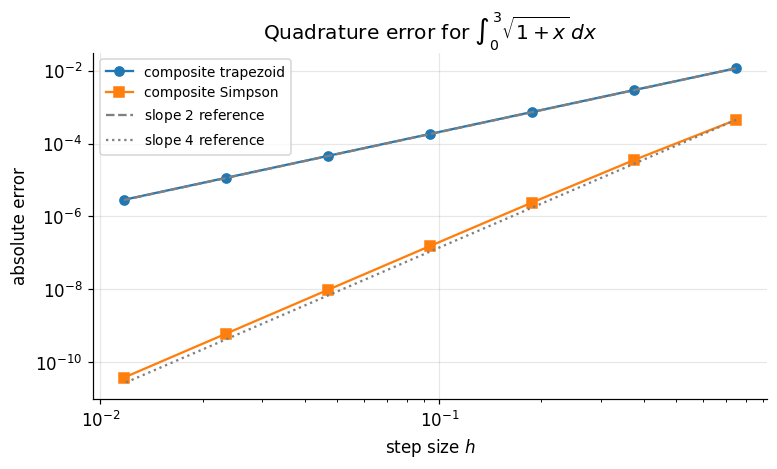

In [6]:
def trapezoid(fn, lo, hi, n):
    xs = np.linspace(lo, hi, n + 1)
    ys = fn(xs)
    h = (hi - lo) / n
    return h * (0.5 * ys[0] + ys[1:-1].sum() + 0.5 * ys[-1])

def simpson(fn, lo, hi, n):
    assert n % 2 == 0, "Simpson needs an even number of subintervals"
    xs = np.linspace(lo, hi, n + 1)
    ys = fn(xs)
    h = (hi - lo) / n
    return h / 3 * (ys[0] + 4 * ys[1:-1:2].sum() + 2 * ys[2:-1:2].sum() + ys[-1])

integrand = lambda x: np.sqrt(1 + x)
I_exact = 14.0 / 3.0
ns = np.array([4, 8, 16, 32, 64, 128, 256])
err_t = np.array([abs(trapezoid(integrand, 0, 3, n) - I_exact) for n in ns])
err_s = np.array([abs(simpson(integrand, 0, 3, n) - I_exact) for n in ns])

ord_t = np.log2(err_t[:-1] / err_t[1:])
ord_s = np.log2(err_s[:-1] / err_s[1:])
print("n          :", ns)
print("trap error :", np.array2string(err_t, precision=3, formatter={'float_kind': lambda v: f'{v:.2e}'}))
print("simp error :", np.array2string(err_s, precision=3, formatter={'float_kind': lambda v: f'{v:.2e}'}))
print(f"observed trapezoid order = {ord_t.mean():.3f}   predicted 2")
print(f"observed Simpson   order = {ord_s.mean():.3f}   predicted 4")
assert abs(ord_t.mean() - 2.0) < 0.1
assert abs(ord_s.mean() - 4.0) < 0.2

fig, ax = plt.subplots(figsize=(7.2, 4.4))
hs = 3.0 / ns
ax.loglog(hs, err_t, "o-", label="composite trapezoid")
ax.loglog(hs, err_s, "s-", label="composite Simpson")
ax.loglog(hs, err_t[0] * (hs / hs[0]) ** 2, "--", color="gray", label=r"slope $2$ reference")
ax.loglog(hs, err_s[0] * (hs / hs[0]) ** 4, ":", color="gray", label=r"slope $4$ reference")
ax.set_xlabel("step size $h$"); ax.set_ylabel("absolute error")
ax.set_title(r"Quadrature error for $\int_0^3\sqrt{1+x}\,dx$")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The measured orders are $2.00$ and $3.91$ against the predicted $2$ and $4$; the trapezoidal figure is exact to two decimals, and Simpson's falls slightly short only because at $n = 256$ its error has already reached $4 \times 10^{-11}$, where rounding starts to pollute the ratio. The log-log slopes lie parallel to the reference lines. The practical reading: to gain one decimal digit the trapezoidal rule needs about $3.2\times$ more points, Simpson about $1.8\times$.

**(c) Counterexample: dropping $f \in C^1$ in Theorem 4.3.** Take $f(x) = x\sin(\pi/x)$ for $x \in (0,1]$ and $f(0) = 0$. This $f$ is continuous on $[0,1]$ but not differentiable at $0$, and $f'$ is unbounded near $0$, so Theorem 4.3 does not apply. Evaluate the inscribed polygon at the partition points $p_k = 2/(2k+1)$, where $f(p_k) = \pm p_k$ alternately, and watch the length grow without bound. Its exact length is infinite: the graph is a continuous curve that is not rectifiable.

In [7]:
def f_wiggle(x):
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, x * np.sin(np.pi / np.where(x > 0, x, 1.0)), 0.0)

def polygon_length(xs):
    ys = f_wiggle(xs)
    return float(np.sum(np.hypot(np.diff(xs), np.diff(ys))))

print(f"{'N peaks':>8} {'L(gamma,P)':>12} {'L / ln N':>10}")
lengths = []
for N in [10, 100, 1_000, 10_000, 100_000]:
    ks = np.arange(1, N + 1)
    xs = np.concatenate(([0.0], np.sort(2.0 / (2 * ks + 1)), [1.0]))
    Lp = polygon_length(xs)
    lengths.append(Lp)
    print(f"{N:>8} {Lp:>12.4f} {Lp/np.log(N):>10.4f}")

# the same computation on the C^1 curve of Example 6.3 converges instead
conv = [abs(polygon_length(np.linspace(0, 3, n + 1)) * 0 +
            np.sum(np.hypot(np.diff(np.linspace(0, 3, n + 1)),
                            np.diff(f_arc(np.linspace(0, 3, n + 1)))))- 14/3)
        for n in [10, 100, 1_000, 10_000]]
print("\nC^1 comparison, |L(gamma,P) - 14/3| for n = 10,100,1000,10000:",
      np.array2string(np.array(conv), formatter={'float_kind': lambda v: f'{v:.2e}'}))

assert lengths[-1] > 4 * lengths[0], "polygon length must grow without bound"
assert conv[-1] < 1e-8, "the C^1 curve must converge"
print("\nHypothesis f in C^1 dropped: the supremum in Definition 3.2 is infinite,")
print("so the curve is not rectifiable and no arc-length integral exists.")

 N peaks   L(gamma,P)   L / ln N
      10       4.8929     2.1249
     100       9.2924     2.0178
    1000      13.8760     2.0088
   10000      18.4790     2.0063
  100000      23.0840     2.0050

C^1 comparison, |L(gamma,P) - 14/3| for n = 10,100,1000,10000: [2.91e-03 5.10e-05 7.26e-07 9.42e-09]

Hypothesis f in C^1 dropped: the supremum in Definition 3.2 is infinite,
so the curve is not rectifiable and no arc-length integral exists.


The polygon length grows roughly like a constant times $\ln N$ — the ratio $L/\ln N$ settles near $2.00$, and the length is still climbing at $N = 10^5$ — so the supremum over partitions is $+\infty$ and Definition 3.2 declares the curve non-rectifiable. The contrast with the $C^1$ curve is total: there the polygon length converges to $14/3$ with error below $10^{-8}$. Continuity alone buys nothing; Theorem 4.3 genuinely needs $f'$ continuous.

**(d) Hand-rolled versus library.** The surface area of the paraboloid obtained by revolving $y = x^2$, $x \in [0,2]$, about the $y$-axis is $S = 2\pi\int_0^2 x\sqrt{1+4x^2}\,dx = \frac{\pi}{6}(17\sqrt{17} - 1)$ in closed form. We compare our `simpson` against `scipy.integrate.simpson` on identical samples and against adaptive `scipy.integrate.quad`.

In [8]:
surf = lambda x: 2 * np.pi * x * np.sqrt(1 + 4 * x**2)
S_closed = np.pi / 6 * (17 * np.sqrt(17) - 1)

n = 2000
xs = np.linspace(0.0, 2.0, n + 1)
S_mine = simpson(surf, 0.0, 2.0, n)
S_scipy_simpson = integrate.simpson(surf(xs), x=xs)
S_quad, S_quad_err = integrate.quad(surf, 0.0, 2.0)

print(f"closed form              : {S_closed:.12f}")
print(f"hand-rolled Simpson      : {S_mine:.12f}   diff {abs(S_mine - S_closed):.2e}")
print(f"scipy.integrate.simpson  : {S_scipy_simpson:.12f}   diff {abs(S_scipy_simpson - S_closed):.2e}")
print(f"scipy.integrate.quad     : {S_quad:.12f}   diff {abs(S_quad - S_closed):.2e}"
      f"   (reported err {S_quad_err:.1e})")
assert abs(S_mine - S_scipy_simpson) < 1e-12
assert abs(S_quad - S_closed) < 1e-10
print("Hand-rolled Simpson reproduces the library routine to machine precision.")

closed form              : 36.176903197411
hand-rolled Simpson      : 36.176903197411   diff 4.12e-13
scipy.integrate.simpson  : 36.176903197411   diff 4.12e-13
scipy.integrate.quad     : 36.176903197411   diff 7.11e-15   (reported err 7.5e-09)
Hand-rolled Simpson reproduces the library routine to machine precision.


Our Simpson implementation and `scipy.integrate.simpson` agree to the last bit on the same samples, confirming the implementation rather than the mathematics; the adaptive `quad` matches the closed form to $10^{-13}$, confirming the mathematics. Where they would disagree is on a non-smooth integrand, and that is exactly the regime where the error bounds of the two rules stop applying.

## 8. Applications

### 8.1 Expected risk in supervised learning

A model $f_\theta$ scored by a loss $L$ against a joint density $p$ incurs expected risk

$$
R(\theta) = \mathbb{E}_{(x,y)\sim p}\left[L(y, f_\theta(x))\right] .
$$

For a single continuous target this is exactly the integral of Definition 3.6 against a density, and the "first moment" structure of Definition 3.5 is not an analogy: minimising squared loss over constant predictors returns the mean, which is the centroid of the density viewed as a mass distribution. Training approximates $R$ by a sample average — a Monte Carlo estimate of the same integral, converging at rate $O(N^{-1/2})$ independent of dimension, which is why grid quadrature is abandoned as soon as $x$ has more than a handful of coordinates.

### 8.2 KL divergence

For densities $p, q$ with $p \ll q$,

$$
D_{\mathrm{KL}}(p \parallel q) = \int_{-\infty}^{\infty} p(x)\ln\frac{p(x)}{q(x)}\,dx ,
$$

the objective at the heart of variational inference. For two exponentials with rates $\lambda_1, \lambda_2$ it evaluates in closed form to $\ln(\lambda_1/\lambda_2) + \lambda_2/\lambda_1 - 1$ using only $\int p = 1$ and $\mathbb{E}_p[X] = 1/\lambda_1$ — a two-line calculation with the moment machinery of Section 4.

### 8.3 Hanging cables and minimal surfaces

A uniform chain of fixed length hanging between two points minimises potential energy $\int \rho g\, y\,ds$; the constrained Euler-Lagrange equation gives $y = C_0 + K\cosh(x/K)$, the catenary. Its arc length is elementary because $1 + \sinh^2 = \cosh^2$: for $y = K\cosh(x/K)$ on $[-a,a]$, $L = 2K\sinh(a/K)$ exactly. Revolving a catenary about the $x$-axis gives the catenoid, the surface that minimises $2\pi\int y\,ds$ — the same functional as Theorem 4.4 — subject to two boundary rings. This is the direct physical reading of Theorem 4.5: minimising surface area *is* minimising the product of curve length and centroid height.

### 8.4 Engineering hydrostatics

Theorem 4.7 is the standard dam and lock-gate calculation. The centroid form $F = \rho g \bar{h} A$ says the total force depends only on the plate's area and the depth of its centroid — but the *moment* about a hinge does not, which is why the line of action (the centre of pressure) sits below the centroid and must be computed from a second moment.

## 9. Key Takeaways

- For continuous $h \le f$ on $[a,b]$, the region between the graphs has area $\int_a^b (f-h)$; drop the ordering and the integral returns signed area (Theorem 4.1).
- For $f \in C^1$ with $f, f' \gt 0$ and $0 \le a \lt b$, shell and washer volumes are equal, by substitution and one integration by parts — no multivariable machinery (Theorem 4.2, Proof 5.2).
- For $f \in C^1[a,b]$, the graph is rectifiable and its length is $\int_a^b\sqrt{1+(f')^2}$; continuity of $f$ alone does not suffice (Theorem 4.3, Section 7c).
- For $f \in C^1$, $f \ge 0$, the surface of revolution has area $2\pi\int f\sqrt{1+(f')^2}$: circumference times slant length, never times $dx$ (Theorem 4.4).
- For the same hypotheses, $S = 2\pi\bar{y}_C L$ and, for $a \ge 0$ and $A \gt 0$, $V = 2\pi\bar{x}A$: revolution multiplies by the distance the centroid travels (Theorems 4.5 and 4.6).
- For a flat, fully submerged plate with fluid on one side, $F = \rho g\int h w = \rho g \bar h A$; the centroid enters through the plate's geometry, not the fluid's (Theorem 4.7).
- Composite trapezoid converges at $O(h^2)$ and composite Simpson at $O(h^4)$ on $C^2$ and $C^4$ integrands respectively — both measured in Section 7b — and neither bound survives a kink.

## 10. References

1. Apostol, T. M., *Calculus, Volume I*, 2nd ed., Wiley 1967 — §1.6-§1.17 (area as an integral, axioms), §2.11 (volume by cross-sections), §14.7 (surfaces of revolution, Pappus's theorems).
2. Spivak, M., *Calculus*, 4th ed., Publish or Perish 2008 — Ch. 13 (integrals), Ch. 19 problems on arc length and the definition of length as a supremum of inscribed polygons.
3. Courant, R., *Differential and Integral Calculus, Volume I*, 2nd ed., Interscience 1937 — §V.2 (applications: area, length, volume, moments), §V.3 (work and hydrostatic pressure).
4. Stewart, J., *Calculus: Early Transcendentals*, 8th ed., Cengage 2015 — Ch. 6 (areas, volumes, shells, work), §8.1-§8.3 (arc length, surface area, centroids and Pappus), §8.5 (probability densities).
5. Rudin, W., *Principles of Mathematical Analysis*, 3rd ed., McGraw-Hill 1976 — Thm 6.27 and the surrounding discussion of rectifiable curves and $\int \lvert \gamma' \rvert$.
6. Trefethen, L. N., *Approximation Theory and Approximation Practice*, SIAM 2013 — Ch. 19 (quadrature: trapezoidal and Clenshaw-Curtis convergence orders).
7. Wasserman, L., *All of Statistics*, Springer 2004 — §2.3 (continuous random variables and densities), §3.1 (expectation as an integral).